# Лабораторная работа 4 — Классификация
**Датасет:** `asteroids_cleaned.csv` | **Цель:** `hazardous` (0 — безопасный, 1 — опасный)

**Метрики оценки:** Accuracy · Precision · Recall · F1 (weighted)

---
### Структура ноутбука
| Раздел | Содержание |
|--------|-----------|
| 0 | Импорты и константы |
| 1 | Загрузка данных |
| 2 | Разделение данных (Holdout + K-Fold) |
| 2.5 | **Обработка дисбаланса классов** (SMOTE + порог) |
| 3.1 | DecisionTreeClassifier + подбор гиперпараметров 3 способами |
| 3.2 | Ансамбли sklearn (Bagging, RF, GBT, AdaBoost, Stacking) |
| 3.3 | CatBoost · XGBoost · LightGBM |
| 4 | Сравнение с PyCaret |
| 5 | Итоговые таблицы |
| 6 | Вывод |

---
### Применяемые техники обработки дисбаланса
| Техника | Где применяется |
|---------|----------------|
| **SMOTE** + **TomekLinks** | Обучающая выборка для всех моделей |
| **Подбор порога** (≠ 0.5) | Финальная оценка каждой модели на holdout-test |

`class_weight` не используется: после SMOTE классы сбалансированы ~50/50, поэтому `class_weight='balanced'` даёт веса ≈ 1 — избыточно.

## Раздел 0. Импорты и константы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import randint, uniform

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier,
                               StackingClassifier)

from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB            
from sklearn.linear_model import LogisticRegression  


from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, StratifiedKFold,
                                      cross_val_predict, cross_validate,
                                      cross_val_score)

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, roc_curve, roc_auc_score)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from joblib import parallel_backend

RANDOM_STATE = 42

## Вспомогательные функции

In [2]:
# Подбор оптимального порога классификации
def find_best_threshold(model, X_val, y_val):
    """
    Ищет порог вероятности (вместо дефолтного 0.5), максимизирующий F1 binary (класс 1)
    на валидационной выборке. Использует только X_val/y_val.

    При дисбалансе классов порог 0.5 часто занижает recall для меньшинства.
    Более низкий порог -> модель чаще предсказывает класс 1 -> выше recall для опасных.
    """
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 91)  # шаг 0.01

    best_thresh, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (proba >= t).astype(int)
        score = f1_score(y_val, preds, average='binary', zero_division=0)
        if score > best_f1:
            best_f1  = score
            best_thresh = t

    return round(float(best_thresh), 2), round(best_f1, 4)


def plot_threshold_curve(model, X_val, y_val):
    """Визуализирует F1 binary в зависимости от порога классификации."""
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 91)
    f1_scores = [
        f1_score(y_val, (proba >= t).astype(int), average='binary', zero_division=0)
        for t in thresholds
    ]
    best_t, best_f = find_best_threshold(model, X_val, y_val)

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
    plt.axvline(best_t, color='red', linestyle='--',
                label=f'Оптимальный порог = {best_t}  (F1={best_f:.4f})')
    plt.axvline(0.5, color='gray', linestyle=':', label='Дефолтный порог = 0.5')
    plt.xlabel('Порог классификации')
    plt.ylabel('F1 binary (на val)')
    plt.title('Подбор порога классификации')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Оценка метрик с учётом пользовательского порога
def eval_clf(model, name, X_train, y_train, X_test, y_test, results,
             threshold=0.5):
    """
    Вычисляет Accuracy, а также Precision / Recall / F1 (binary) на train и test.
    Если threshold != 0.5 и модель поддерживает predict_proba - применяет
    кастомный порог вместо дефолтного.
    """
    use_proba = (threshold != 0.5) and hasattr(model, 'predict_proba')

    if use_proba:
        # Вызываем predict_proba строго один раз для каждого датасета
        proba_train = model.predict_proba(X_train)[:, 1]
        proba_test = model.predict_proba(X_test)[:, 1]
        
        yt = (proba_train >= threshold).astype(int)
        yp = (proba_test >= threshold).astype(int)
    else:
        yt = model.predict(X_train)
        yp = model.predict(X_test)

    results.append({
        'Algorithm':  name,
        'Threshold':  threshold,
        'Train Acc':  round(accuracy_score(y_train, yt), 4),
        'Train Prec': round(precision_score(y_train, yt, average='binary', zero_division=0), 4),
        'Train Rec':  round(recall_score(y_train, yt, average='binary', zero_division=0), 4),
        'Train F1':   round(f1_score(y_train, yt, average='binary', zero_division=0), 4),
        'Test Acc':   round(accuracy_score(y_test, yp), 4),
        'Test Prec':  round(precision_score(y_test, yp, average='binary', zero_division=0), 4),
        'Test Rec':   round(recall_score(y_test, yp, average='binary', zero_division=0), 4),
        'Test F1':    round(f1_score(y_test, yp, average='binary', zero_division=0), 4),
    })

    thresh_note = f"(порог={threshold})" if use_proba else "(порог=0.5 дефолт)"
    print(f"\nОтчет классификации для: {name} {thresh_note}\n")

    report_dict = classification_report(y_test, yp, zero_division=0, output_dict=True)
    
    acc_value = round(report_dict.pop('accuracy'), 4)
    
    df_report = pd.DataFrame(report_dict).transpose().round(4)
    
    df_report.index = df_report.index.map(
        lambda x: f"Класс {x} (Безопасные)" if x == '0' else 
                  (f"Класс {x} (Опасные)" if x == '1' else x)
    )
    
    # Печатаем общую метрику строгим аккуратным текстом над таблицей
    print(f"Accuracy: {acc_value}")
    
    return df_report


def kfold_clf(model, name, X, y, cv, results, threshold=0.5):
    """
    K-Fold оценка. При кастомном пороге использует cross_val_predict
    для получения OOF-вероятностей -> применяет порог -> считает бинарные метрики.
    """
    use_proba = (threshold != 0.5) and hasattr(model, 'predict_proba')

    if use_proba:
        # Out-of-fold вероятности — честная оценка без утечки данных
        oof_proba = cross_val_predict(
            model, X, y, cv=cv, method='predict_proba', n_jobs=-1
        )[:, 1]
        y_pred = (oof_proba >= threshold).astype(int)
        
        results.append({
            'Algorithm':  name,
            'Threshold':  threshold,
            'Train Acc':  np.nan,   # OOF не даёт train-метрику
            'Train Prec': np.nan,
            'Train Rec':  np.nan,
            'Train F1':   np.nan,
            'Test Acc':   round(accuracy_score(y, y_pred), 4),
            'Test Prec':  round(precision_score(y, y_pred, average='binary', zero_division=0), 4),
            'Test Rec':   round(recall_score(y, y_pred, average='binary', zero_division=0), 4),
            'Test F1':    round(f1_score(y, y_pred, average='binary', zero_division=0), 4),
        })
        print(f"\n{name} | KFold-10 OOF (порог={threshold})")
        print(f"  OOF F1 (Binary): {results[-1]['Test F1']:.4f}")
    else:
        sc = cross_validate(
            model, X, y, cv=cv,
            scoring=['accuracy', 'precision', 'recall', 'f1'],
            return_train_score=True, n_jobs=-1
        )
        results.append({
            'Algorithm':  name,
            'Threshold':  0.5,
            'Train Acc':  round(sc['train_accuracy'].mean(), 4),
            'Train Prec': round(sc['train_precision'].mean(), 4),
            'Train Rec':  round(sc['train_recall'].mean(), 4),
            'Train F1':   round(sc['train_f1'].mean(), 4),
            'Test Acc':   round(sc['test_accuracy'].mean(), 4),
            'Test Prec':  round(sc['test_precision'].mean(), 4),
            'Test Rec':   round(sc['test_recall'].mean(), 4),
            'Test F1':    round(sc['test_f1'].mean(), 4),
        })
        print(f"\n{name} | StratifiedKFold-10")
        print(f"  Test Acc: {sc['test_accuracy'].mean():.4f} ± {sc['test_accuracy'].std():.4f}")
        print(f"  Test F1 (Binary):  {sc['test_f1'].mean():.4f} ± {sc['test_f1'].std():.4f}")


In [ ]:
def tune_model_3ways(model_cls, model_kwargs,
                     param_grid, param_dist, suggest_fn,
                     X_train, y_train, X_val, y_val,
                     score_fn=None,
                     sklearn_scoring='roc_auc',  # Перевели внутренний CV на ROC-AUC
                     n_iter=20, n_trials=30, jobs = None):
    """
    Подбирает гиперпараметры тремя способами:
      1. GridSearchCV        — 10-Fold CV по тренировочным (SMOTE) данным
      2. RandomizedSearchCV  — 10-Fold CV по тренировочным (SMOTE) данным
      3. Optuna (TPE)        — Байесовский поиск напрямую на валидационных (оригинальных) данных
    
    Критерий оптимизации — ROC-AUC. Порог подбирается ОТДЕЛЬНО после этой функции.
    """
    # score_fn теперь считает ROC-AUC по непрерывным вероятностям класса 1
    if score_fn is None:
        score_fn = lambda m, X, y: roc_auc_score(
            y, m.predict_proba(X)[:, 1]
        )

    candidates = {}

    if jobs is None:
        act_jobs = -1
    else:
        act_jobs = 1

    # 1. GridSearchCV
    # Ищет лучший ROC-AUC на 10 внутренних фолдах SMOTE-выборки, делает refit
    grid = GridSearchCV(
        model_cls(**model_kwargs), param_grid,
        cv=10, scoring=sklearn_scoring, n_jobs=act_jobs, refit=True
    )
    grid.fit(X_train, y_train)
    candidates['GridSearchCV'] = {
        'params':    grid.best_params_,
        # Финальный скор считаем по честным валидационным данным без SMOTE
        'val_score': score_fn(grid.best_estimator_, X_val, y_val),
        'model':     grid.best_estimator_,
    }

    # 2. RandomizedSearchCV
    rand = RandomizedSearchCV(
        model_cls(**model_kwargs), param_dist,
        n_iter=n_iter, cv=10, scoring=sklearn_scoring,
        n_jobs=act_jobs, random_state=RANDOM_STATE, refit=True
    )
    rand.fit(X_train, y_train)
    candidates['RandomizedSearchCV'] = {
        'params':    rand.best_params_,
        'val_score': score_fn(rand.best_estimator_, X_val, y_val),
        'model':     rand.best_estimator_,
    }

    # 3. Optuna (TPE)
    # Обучается на SMOTE, но оценивает каждую итерацию по ROC-AUC на оригинальном X_val
    def objective(trial):
        params = suggest_fn(trial)
        m = model_cls(**{**model_kwargs, **params})
        m.fit(X_train, y_train)
        return score_fn(m, X_val, y_val)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_optuna = model_cls(**{**model_kwargs, **study.best_params})
    best_optuna.fit(X_train, y_train)
    candidates['Optuna (TPE)'] = {
        'params':    study.best_params,
        'val_score': score_fn(best_optuna, X_val, y_val),
        'model':     best_optuna,
    }

    # Таблица сравнения методов
    df_cmp = pd.DataFrame([
        {'Метод': k, 'Лучшие параметры': str(v['params']),
         'Val ROC-AUC': round(v['val_score'], 4)}
        for k, v in candidates.items()
    ])
    
    with pd.option_context('display.max_colwidth', None):
        display(df_cmp)

    winner = max(candidates, key=lambda k: candidates[k]['val_score'])
    print(f"\nПобедитель: {winner} | Val ROC-AUC = {candidates[winner]['val_score']:.4f}")

    return candidates[winner]['model'], df_cmp

In [5]:
def tune_kfold_pipeline(model_cls, model_kwargs,
                         param_grid, param_dist, suggest_fn,
                         X, y, cv, n_iter=10, n_trials=15, jobs = None):
    """
    Подбор гиперпараметров для K-Fold через ImbPipeline (SMOTE внутри каждого фолда).
    Поиск: RandomizedSearchCV + Optuna на 5-fold (быстро).
    OOF победителя: 1 cross_val_predict на полном cv (честно).
    Возвращает: (best_pipe, best_thresh, best_oof) — OOF готов, kfold_clf не нужен.
    """
    pipe_dist = {f'clf__{k}': v for k, v in param_dist.items()}
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def make_pipe(**kw):
        return ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('clf',   model_cls(**{**model_kwargs, **kw}))
        ])

    if jobs is None:
        act_jobs = -1
    else:
        act_jobs = 1

    # 1. RandomizedSearchCV (5-fold)
    rscv = RandomizedSearchCV(make_pipe(), pipe_dist,
                               n_iter=n_iter, cv=inner_cv, scoring='roc_auc',
                               n_jobs=act_jobs, random_state=RANDOM_STATE, refit=True)
    rscv.fit(X, y)

    # 2. Optuna (5-fold в objective)
    def objective(trial):
        return cross_val_score(
            make_pipe(**suggest_fn(trial)), X, y,
            cv=inner_cv, scoring='roc_auc', n_jobs=act_jobs
        ).mean()

    study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    opt_pipe = make_pipe(**study.best_params)
    opt_pipe.fit(X, y)

    candidates = {
        'RandomizedSearchCV': (rscv.best_score_,  rscv.best_estimator_),
        'Optuna (TPE)':       (study.best_value,   opt_pipe),
    }
    df_cmp = pd.DataFrame([
        {'Метод': k, 'CV ROC-AUC (5-fold)': round(v[0], 4)}
        for k, v in candidates.items()
    ])
    with pd.option_context('display.max_colwidth', None):
        display(df_cmp)

    winner = max(candidates, key=lambda k: candidates[k][0])
    best_pipe = candidates[winner][1]
    print(f"\nПобедитель (KFold): {winner} | CV ROC-AUC = {candidates[winner][0]:.4f}")

    # Один cross_val_predict для победителя (10-fold)
    best_oof = cross_val_predict(
        best_pipe, X, y, cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    best_thresh = round(float(max(
        np.linspace(0.05, 0.95, 91),
        key=lambda t: f1_score(y, (best_oof >= t).astype(int),
                               average='binary', zero_division=0)
    )), 2)
    oof_f1 = round(f1_score(y, (best_oof >= best_thresh).astype(int),
                             average='binary', zero_division=0), 4)
    print(f"Оптимальный порог (OOF): {best_thresh}  (F1={oof_f1:.4f})")

    return best_pipe, best_thresh, best_oof


def _kfold_append(name, thresh, oof, y, results):
    """Записывает OOF-метрики в results без повторного cross_val_predict."""
    yp = (oof >= thresh).astype(int)
    results.append({
        'Algorithm':  name,
        'Threshold':  thresh,
        'Train Acc':  np.nan, 'Train Prec': np.nan,
        'Train Rec':  np.nan, 'Train F1':   np.nan,
        'Test Acc':   round(accuracy_score(y, yp), 4),
        'Test Prec':  round(precision_score(y, yp, average='binary', zero_division=0), 4),
        'Test Rec':   round(recall_score(y, yp, average='binary', zero_division=0), 4),
        'Test F1':    round(f1_score(y, yp, average='binary', zero_division=0), 4),
    })
    print(f"\n{name} | KFold-10 OOF (порог={thresh})")
    print(f"  OOF F1 (Binary): {results[-1]['Test F1']:.4f}")

## Раздел 1. Загрузка данных

In [6]:
df = pd.read_csv('asteroids_cleaned.csv')

X = df.drop('hazardous', axis=1)
y = df['hazardous']

print(f"Размер датасета: {df.shape}")
print(f"Признаки: {list(X.columns)}")
print(f"\nРаспределение классов:")
vc = y.value_counts()
ratio = vc[0] / vc[1]
print(f"  0 (безопасные): {vc[0]:6d} ({vc[0]/len(y)*100:.1f}%)")
print(f"  1 (опасные):    {vc[1]:6d} ({vc[1]/len(y)*100:.1f}%)")
print(f"\nСоотношение классов: {ratio:.1f} к 1 -> значительный дисбаланс")
print(f"Используем SMOTE + подбор порога")

Размер датасета: (88534, 6)
Признаки: ['year', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

Распределение классов:
  0 (безопасные):  79938 (90.3%)
  1 (опасные):      8596 (9.7%)

Соотношение классов: 9.3 к 1 -> значительный дисбаланс
Используем SMOTE + подбор порога


## Раздел 2. Разделение данных

In [7]:
# Holdout:
# X, y -> train 60% / temp 40% 
# temp 30% -> val 20% / test 20%
# stratify=y гарантирует сохранение пропорций классов в каждой части

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print("Holdout разбивка:")
print(f"  Train: {len(X_train):5d} ({len(X_train)/len(X)*100:.1f}%)  |  "
      f"класс 1: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Val:   {len(X_val):5d} ({len(X_val)/len(X)*100:.1f}%)  |  "
      f"класс 1: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  Test:  {len(X_test):5d} ({len(X_test)/len(X)*100:.1f}%)  |  "
      f"класс 1: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Holdout разбивка:
  Train: 53120 (60.0%)  |  класс 1: 5158 (9.7%)
  Val:   17707 (20.0%)  |  класс 1: 1719 (9.7%)
  Test:  17707 (20.0%)  |  класс 1: 1719 (9.7%)


In [8]:
# Stratified K-Fold (k=10) гарантирует, что в каждом фолде доля класса 1 ≈ 9.7%

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
X_full, y_full = X, y

## Раздел 2.5. Обработка дисбаланса классов

Датасет содержит примерно 90% безопасных и 10% опасных астероидов.
Используем два взаимодополняющих подхода:

---
### Техника 1: SMOTE + TomekLinks
**Что делает:** SMOTE создаёт **синтетические** образцы меньшинства (класс 1) в пространстве признаков.
Не просто дублирует существующие объекты, а интерполирует между ними. TomekLinks убирает пограничные пары (безопасный + опасный, стоящие близко) из обучающей выборки, граница решения становится чище, модель увереннее разделяет класс.

**Где применяется:** только на `X_train` -> `X_train_sm`.
`X_val` и `X_test` **не трогаем** — иначе оценка будет нечестной (утечка данных).

---
### Техника 2: Подбор порога классификации
**Что делает:** вместо дефолтного порога 0.5 ищет порог $t^*$, максимизирующий F1 binary на `X_val`.

**Логика:** при дисбалансе P(y=1) < P(y=0), поэтому вероятности для класса 1 занижены.
Снижая порог (например, с 0.5 до 0.3), повышаем чувствительность модели к целевому классу.

In [9]:
# SMOTE в купе с TomekLinks применяем только к обучающей выборке
# В отличии от лабы 2, деревьям и ансамблям не требуется стандартизация

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

tl = TomekLinks(sampling_strategy='majority')
X_train_sm, y_train_sm = tl.fit_resample(X_train_sm, y_train_sm)

print("SMOTE и TomekLinks применены к X_train:")
print(f"  До: {dict(y_train.value_counts().sort_index())}")
print(f"  После: {dict(pd.Series(y_train_sm).value_counts().sort_index())}")
print(f"  Новый размер обучающей выборки: {len(X_train_sm)}")

SMOTE и TomekLinks применены к X_train:
  До: {0: 47962, 1: 5158}
  После: {0: 42892, 1: 47962}
  Новый размер обучающей выборки: 90854


In [10]:
# Накопители результатов 
results_holdout = []  # holdout-метрики с кастомным порогом
results_kfold   = []  # kfold-метрики

## Раздел 3.1. DecisionTreeClassifier

**Применяемые техники устранения дисбаланса:**
- **SMOTE** + **TomekLinks** — обучение на `X_train_sm`
- **Подбор порога** — после выбора лучшей модели

### Как работает дерево решений?
Алгоритм **CART** рекурсивно делит пространство признаков на прямоугольные области.
В каждом узле выбирается признак и порог, минимизирующий **примесь** (Gini или Entropy).

| Параметр | Влияние |
|----------|---------|
| `max_depth` | Глубина: маленькое → недообучение, большое → переобучение |
| `min_samples_split` | Минимум объектов для разделения → регуляризация |
| `min_samples_leaf` | Минимум объектов в листе → более сглаженная граница |
| `criterion` | `gini` (быстрее) vs `entropy` (иногда точнее) |

In [11]:
dt_param_grid = {
    'max_depth':        [3, 5, 7, 10, 15, None],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion':        ['gini', 'entropy'],
}
dt_param_dist = {
    'max_depth':        randint(2, 20),
    'min_samples_split':randint(2, 30),
    'min_samples_leaf': randint(1, 15),
    'criterion':        ['gini', 'entropy'],
}
def dt_suggest(trial):
    return {
        'max_depth':        trial.suggest_int('max_depth', 2, 20),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'criterion':        trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

dt_kwargs = {'random_state': RANDOM_STATE}

print("DecisionTreeClassifier - подбор гиперпараметров тремя способами")
print("  Обучение на: X_train_sm (SMOTE)")

# Передаем данные прошедшие через smote - X_train_sm, y_train_sm
best_dt, dt_cmp = tune_model_3ways(
    DecisionTreeClassifier, dt_kwargs,
    dt_param_grid, dt_param_dist, dt_suggest,
    X_train_sm, y_train_sm, X_val, y_val,
    n_iter=30, n_trials=50,
)

DecisionTreeClassifier - подбор гиперпараметров тремя способами
  Обучение на: X_train_sm (SMOTE)


,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}",0.9059
1,RandomizedSearchCV,"{'criterion': 'gini', 'max_depth': 19, 'min_samples_leaf': 5, 'min_samples_split': 25}",0.9037
2,Optuna (TPE),"{'max_depth': 6, 'min_samples_split': 18, 'min_samples_leaf': 6, 'criterion': 'gini'}",0.9080



Победитель: Optuna (TPE) | Val ROC-AUC = 0.9080


Оптимальный порог DecisionTree: 0.5  (F1=0.4777)
Дефолтный порог 0.5 дал бы F1=0.4779


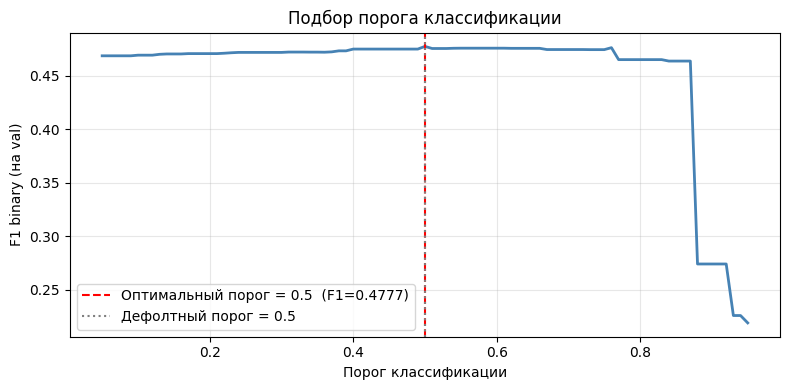

In [12]:
# Подбор порога
best_dt_thresh, val_f1 = find_best_threshold(best_dt, X_val, y_val)
print(f"Оптимальный порог DecisionTree: {best_dt_thresh}  (F1={val_f1:.4f})")
print(f"Дефолтный порог 0.5 дал бы F1={f1_score(y_val, best_dt.predict(X_val), average='binary', zero_division=0):.4f}")
plot_threshold_curve(best_dt, X_val, y_val)

In [13]:
# Финальная оценка на test с оптимальным порогом
eval_clf(best_dt, 'DecisionTree (best)', X_train_sm, y_train_sm,
         X_test, y_test, results_holdout, threshold=best_dt_thresh)


Отчет классификации для: DecisionTree (best) (порог=0.5 дефолт)

Accuracy: 0.8019


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9937,0.7856,0.8775,15988.0
Класс 1 (Опасные),0.3236,0.9540,0.4833,1719.0
macro avg,0.6587,0.8698,0.6804,17707.0
weighted avg,0.9287,0.8019,0.8392,17707.0


- **Recall класса 1 = 0.954** — модель обнаруживает 95% опасных астероидов.
  Пропускается лишь ~5% реально опасных объектов.

- **Precision класса 1 = 0.324** — 68% предсказанных "опасных" оказываются ложной тревогой.
  Приемлемо: лучше лишняя проверка, чем пропущенный астероид.

- **F1 класса 1 = 0.483** — слабовато, но ожидаемо для одиночного дерева решений
  на сильно несбалансированных данных (9:1).

DecisionTree — слабая базовая модель. Ансамблевые методы (RF, XGBoost, CatBoost)
должны значительно улучшить precision при сохранении высокого recall.


Получаем метрики k-fold

In [14]:
# K-Fold: ImbPipeline + отдельный подбор гиперпараметров + OOF-порог
dt_kf_pipe, dt_kf_thresh, dt_kf_oof = tune_kfold_pipeline(
    DecisionTreeClassifier, dt_kwargs,
    dt_param_grid, dt_param_dist, dt_suggest,
    X_full, y_full, skf, n_iter=30, n_trials=50,
)
_kfold_append('DecisionTree (KFold+Pipeline)', dt_kf_thresh, dt_kf_oof, y_full, results_kfold)

,Метод,CV ROC-AUC (5-fold)
0,RandomizedSearchCV,0.9131
1,Optuna (TPE),0.9165



Победитель (KFold): Optuna (TPE) | CV ROC-AUC = 0.9165
Оптимальный порог (OOF): 0.38  (F1=0.5278)

DecisionTree (KFold+Pipeline) | KFold-10 OOF (порог=0.38)
  OOF F1 (Binary): 0.5278


### Визуализация и решающие правила

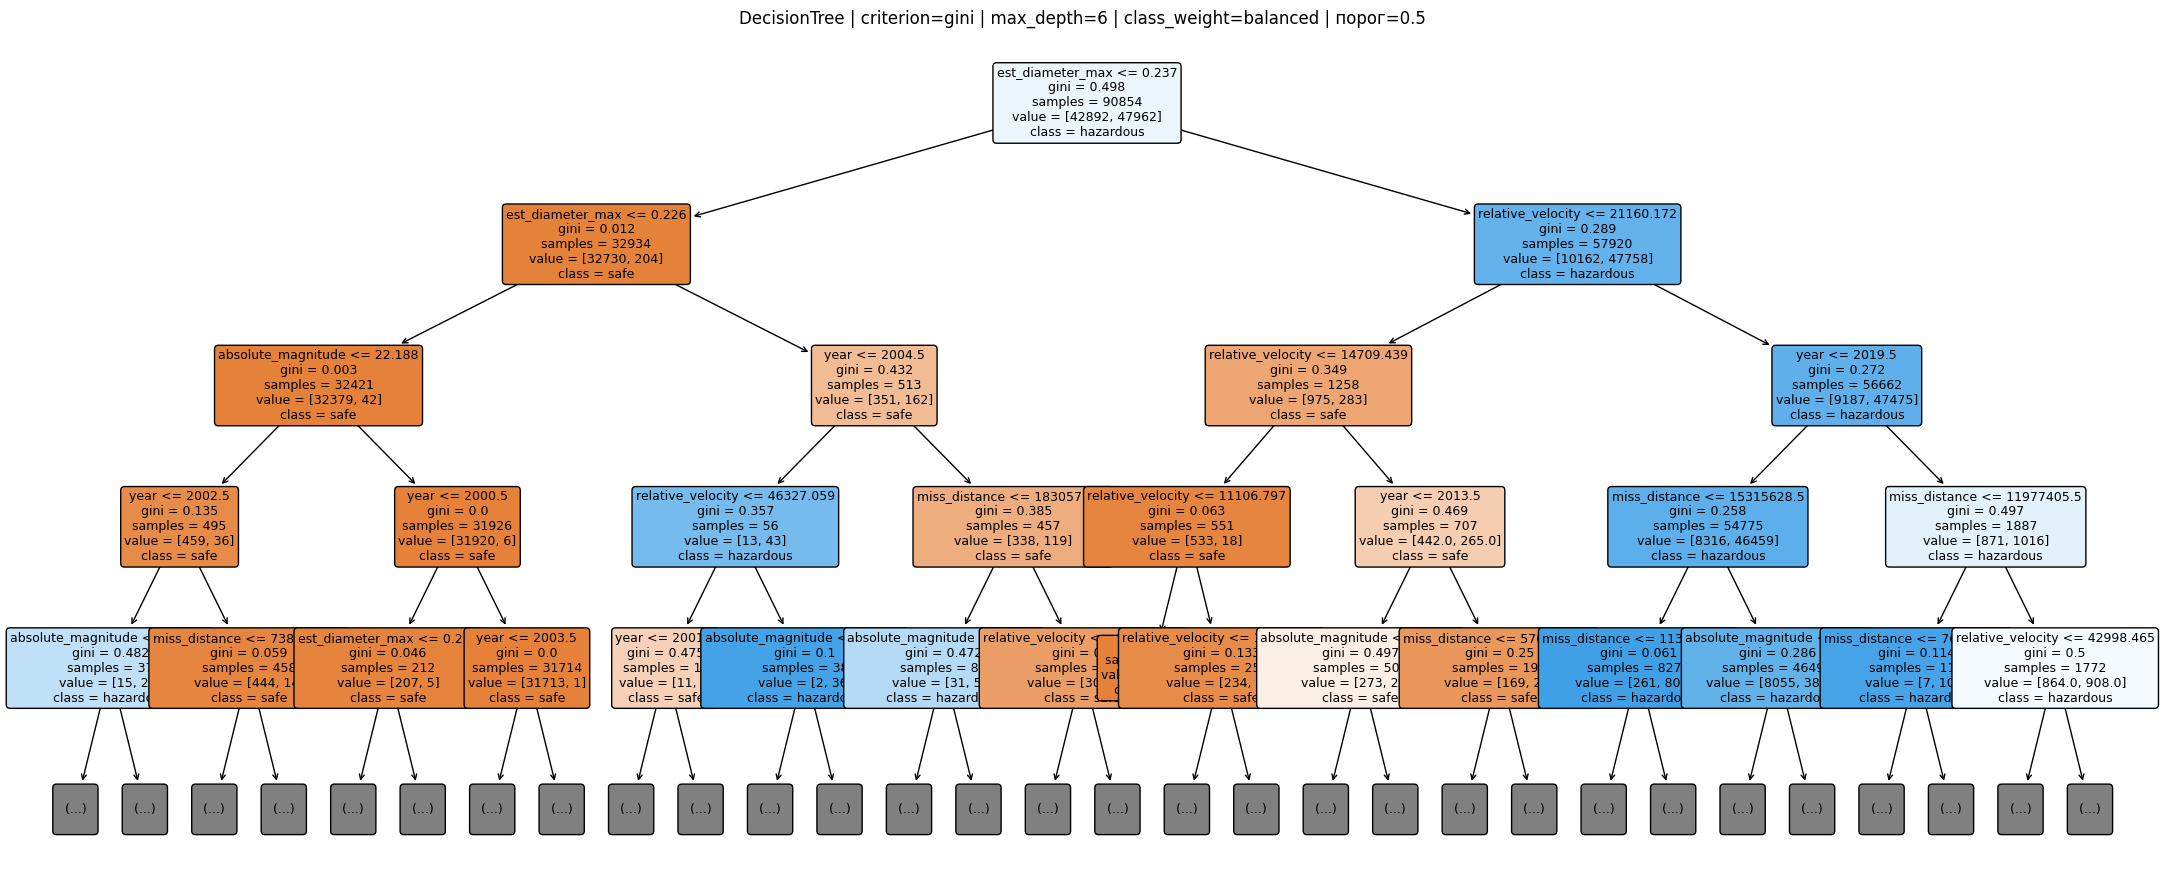

In [15]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(best_dt, feature_names=X.columns.tolist(),
          class_names=['safe','hazardous'], filled=True, rounded=True,
          max_depth=4, ax=ax, fontsize=9)
plt.title(
    f'DecisionTree | criterion={best_dt.criterion} | max_depth={best_dt.max_depth} '
    f'| class_weight=balanced | порог={best_dt_thresh}', fontsize=12
)
plt.tight_layout()
plt.show()

In [16]:
rules = export_text(best_dt, feature_names=X.columns.tolist(), max_depth=5)
print("Решающие правила DecisionTreeClassifier:")
print(rules)

Решающие правила DecisionTreeClassifier:
|--- est_diameter_max <= 0.24
|   |--- est_diameter_max <= 0.23
|   |   |--- absolute_magnitude <= 22.19
|   |   |   |--- year <= 2002.50
|   |   |   |   |--- absolute_magnitude <= 22.11
|   |   |   |   |   |--- relative_velocity <= 48520.45
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- relative_velocity >  48520.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- absolute_magnitude >  22.11
|   |   |   |   |   |--- class: 1
|   |   |   |--- year >  2002.50
|   |   |   |   |--- miss_distance <= 7380809.25
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- miss_distance >  7380809.25
|   |   |   |   |   |--- miss_distance <= 72584196.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- miss_distance >  72584196.00
|   |   |   |   |   |   |--- class: 0
|   |   |--- absolute_magnitude >  22.19
|   |   |   |--- year <= 2000.50
|   |   |   |   |--- est_diameter_max <= 0.21
|   |   |   |   |   |--- class: 0


## Раздел 3.2. Ансамбли sklearn

**Применяемые техники устранения дисбаланса:**
- **SMOTE** + **TomekLinks** — обучение на `X_train_sm`
- **Подбор порога** — после выбора лучшей модели

### BaggingClassifier

Bootstrap AGGregatING — параллельный ансамбль. Снижает дисперсию через усреднение.

In [17]:
bag_param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_samples':  [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0],
}
bag_param_dist = {
    'n_estimators': randint(10, 300),
    'max_samples':  uniform(0.3, 0.7),
    'max_features': uniform(0.3, 0.7),
}
def bag_suggest(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 10, 300),
        'max_samples':  trial.suggest_float('max_samples', 0.3, 1.0),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
    }

bag_kwargs = {
    'estimator':    DecisionTreeClassifier(random_state=RANDOM_STATE),
    'random_state': RANDOM_STATE, 'n_jobs': -1,
}

best_bag, _ = tune_model_3ways(
    BaggingClassifier, bag_kwargs,
    bag_param_grid, bag_param_dist, bag_suggest,
    X_train_sm, y_train_sm, X_val, y_val,   # <- SMOTE
    n_iter=20, n_trials=30,
)
bag_thresh, _ = find_best_threshold(best_bag, X_val, y_val)
print(f"Оптимальный порог Bagging: {bag_thresh}")



# K-Fold: ImbPipeline + отдельный подбор гиперпараметров + OOF-порог
bag_kf_pipe, bag_kf_thresh, bag_kf_oof = tune_kfold_pipeline(
    BaggingClassifier, bag_kwargs,
    bag_param_grid, bag_param_dist, bag_suggest,
    X_full, y_full, skf, n_iter=10, n_trials=15,
)
_kfold_append('BaggingClassifier (KFold+Pipeline)', bag_kf_thresh, bag_kf_oof, y_full, results_kfold)

,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 200}",0.9499
1,RandomizedSearchCV,"{'max_features': 0.5564532903055841, 'max_samples': 0.619248988951925, 'n_estimators': 184}",0.9341
2,Optuna (TPE),"{'n_estimators': 124, 'max_samples': 0.9865232817712635, 'max_features': 0.8544632354849643}",0.9559



Победитель: Optuna (TPE) | Val ROC-AUC = 0.9559
Оптимальный порог Bagging: 0.59


,Метод,CV ROC-AUC (5-fold)
0,RandomizedSearchCV,0.9623
1,Optuna (TPE),0.9630



Победитель (KFold): Optuna (TPE) | CV ROC-AUC = 0.9630
Оптимальный порог (OOF): 0.5  (F1=0.6938)

BaggingClassifier (KFold+Pipeline) | KFold-10 OOF (порог=0.5)
  OOF F1 (Binary): 0.6938


In [18]:
eval_clf(best_bag, 'BaggingClassifier (best)', X_train_sm, y_train_sm,
         X_test, y_test, results_holdout, threshold=bag_thresh)


Отчет классификации для: BaggingClassifier (best) (порог=0.59)

Accuracy: 0.9329


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9580,0.9681,0.9630,15988.0
Класс 1 (Опасные),0.6712,0.6056,0.6367,1719.0
macro avg,0.8146,0.7868,0.7999,17707.0
weighted avg,0.9302,0.9329,0.9314,17707.0


### RandomForestClassifier

Улучшенный Bagging: случайный выбор признаков в каждом узле → менее коррелированные деревья.

In [19]:
rf_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 10, 15, None],
    'min_samples_split':[2, 5, 10],
    'max_features':     ['sqrt', 'log2'],
}
rf_param_dist = {
    'n_estimators':     randint(50, 400),
    'max_depth':        randint(3, 20),
    'min_samples_split':randint(2, 20),
    'max_features':     ['sqrt', 'log2'],
}
def rf_suggest(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 400),
        'max_depth':        trial.suggest_int('max_depth', 3, 20),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

rf_kwargs = {
    'random_state': RANDOM_STATE, 'n_jobs': -1,
}

best_rf, _ = tune_model_3ways(
    RandomForestClassifier, rf_kwargs,
    rf_param_grid, rf_param_dist, rf_suggest,
    X_train_sm, y_train_sm, X_val, y_val,
    n_iter=20, n_trials=40,
)
rf_thresh, _ = find_best_threshold(best_rf, X_val, y_val)
print(f"Оптимальный порог RF: {rf_thresh}")




rf_kf_pipe, rf_kf_thresh, rf_kf_oof = tune_kfold_pipeline(
    RandomForestClassifier, rf_kwargs,
    rf_param_grid, rf_param_dist, rf_suggest,
    X_full, y_full, skf, n_iter=10, n_trials=15,
)
_kfold_append('RandomForestClassifier (KFold+Pipeline)', rf_kf_thresh, rf_kf_oof, y_full, results_kfold)

,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}",0.9515
1,RandomizedSearchCV,"{'max_depth': 19, 'max_features': 'sqrt', 'min_samples_split': 11, 'n_estimators': 237}",0.9346
2,Optuna (TPE),"{'n_estimators': 285, 'max_depth': 20, 'min_samples_split': 4, 'max_features': 'sqrt'}",0.9397



Победитель: GridSearchCV | Val ROC-AUC = 0.9515
Оптимальный порог RF: 0.61


,Метод,CV ROC-AUC (5-fold)
0,RandomizedSearchCV,0.9391
1,Optuna (TPE),0.9397



Победитель (KFold): Optuna (TPE) | CV ROC-AUC = 0.9397
Оптимальный порог (OOF): 0.63  (F1=0.5699)

RandomForestClassifier (KFold+Pipeline) | KFold-10 OOF (порог=0.63)
  OOF F1 (Binary): 0.5699


In [20]:
eval_clf(best_rf, 'RandomForestClassifier (best)', X_train_sm, y_train_sm,
         X_test, y_test, results_holdout, threshold=rf_thresh)


Отчет классификации для: RandomForestClassifier (best) (порог=0.61)

Accuracy: 0.924


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9612,0.9544,0.9578,15988.0
Класс 1 (Опасные),0.6021,0.6417,0.6212,1719.0
macro avg,0.7816,0.7980,0.7895,17707.0
weighted avg,0.9263,0.9240,0.9251,17707.0


### GradientBoostingClassifier

Дисбаланс обрабатывается через SMOTE.
Дополнительно используем `subsample < 1.0` (Stochastic GBT) для регуляризации.

In [25]:
gbc_param_grid = {
    'n_estimators':  [100, 150],       
    'learning_rate': [0.05, 0.1],      
    'max_depth':     [3, 4, 5],        
    'subsample':     [0.7, 0.85],      
}

gbc_param_dist = {
    'n_estimators':  randint(50, 150),  
    'learning_rate': uniform(0.02, 0.18),
    'max_depth':     randint(2, 6),     
    'subsample':     uniform(0.6, 0.3), 
}

def gbc_suggest(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
        'max_depth':     trial.suggest_int('max_depth', 2, 5), 
        'subsample':     trial.suggest_float('subsample', 0.6, 0.9),
    }

gbc_kwargs = {'random_state': RANDOM_STATE}

best_gbc, _ = tune_model_3ways(
    GradientBoostingClassifier, gbc_kwargs,
    gbc_param_grid, gbc_param_dist, gbc_suggest,
    X_train_sm, y_train_sm, X_val, y_val, 
    n_iter=5, n_trials=10,
)
gbc_thresh, _ = find_best_threshold(best_gbc, X_val, y_val)
print(f"Оптимальный порог GBC: {gbc_thresh}")

gbc_kf_pipe, gbc_kf_thresh, gbc_kf_oof = tune_kfold_pipeline(
    GradientBoostingClassifier, gbc_kwargs,
    gbc_param_grid, gbc_param_dist, gbc_suggest,
    X_full, y_full, skf, 
    n_iter=3, n_trials=5,
)
_kfold_append('GradientBoostingClassifier (KFold+Pipeline)', gbc_kf_thresh, gbc_kf_oof, y_full, results_kfold)


,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.85}",0.9270
1,RandomizedSearchCV,"{'learning_rate': 0.1277585271554666, 'max_depth': 4, 'n_estimators': 132, 'subsample': 0.6299924747454009}",0.9231
2,Optuna (TPE),"{'n_estimators': 56, 'learning_rate': 0.1777933581403786, 'max_depth': 5, 'subsample': 0.8425192044349383}",0.9236



Победитель: GridSearchCV | Val ROC-AUC = 0.9270
Оптимальный порог GBC: 0.54


,Метод,CV ROC-AUC (5-fold)
0,RandomizedSearchCV,0.9267
1,Optuna (TPE),0.9253



Победитель (KFold): RandomizedSearchCV | CV ROC-AUC = 0.9267
Оптимальный порог (OOF): 0.57  (F1=0.5289)

GradientBoostingClassifier (KFold+Pipeline) | KFold-10 OOF (порог=0.57)
  OOF F1 (Binary): 0.5289


In [26]:
eval_clf(best_gbc, 'GradientBoostingClassifier (best)', X_train_sm, y_train_sm,
         X_test, y_test, results_holdout, threshold=gbc_thresh)


Отчет классификации для: GradientBoostingClassifier (best) (порог=0.54)

Accuracy: 0.8718


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9703,0.8851,0.9257,15988.0
Класс 1 (Опасные),0.4118,0.7481,0.5312,1719.0
macro avg,0.6910,0.8166,0.7285,17707.0
weighted avg,0.9161,0.8718,0.8874,17707.0


### AdaBoostClassifier

AdaBoost сам адаптирует веса объектов в процессе обучения и частично обрабатывает дисбаланс.
SMOTE инициализирует с более сбалансированным распределением.

In [28]:
ada_param_grid = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5],
}
ada_param_dist = {
    'n_estimators':  randint(30, 300),
    'learning_rate': uniform(0.1, 1.9),
}
def ada_suggest(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 30, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.1, 2.0),
    }

ada_kwargs = {
    'estimator':    DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    'random_state': RANDOM_STATE,
}

best_ada, _ = tune_model_3ways(
    AdaBoostClassifier, ada_kwargs,
    ada_param_grid, ada_param_dist, ada_suggest,
    X_train_sm, y_train_sm, X_val, y_val, 
    n_iter=20, n_trials=30,
)
ada_thresh, _ = find_best_threshold(best_ada, X_val, y_val)
print(f"Оптимальный порог AdaBoost: {ada_thresh}")

ada_kf_pipe, ada_kf_thresh, ada_kf_oof = tune_kfold_pipeline(
    AdaBoostClassifier, ada_kwargs,
    ada_param_grid, ada_param_dist, ada_suggest,
    X_full, y_full, skf, n_iter=10, n_trials=15,
)
_kfold_append('AdaBoostClassifier (KFold+Pipeline)', ada_kf_thresh, ada_kf_oof, y_full, results_kfold)

,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'learning_rate': 1.5, 'n_estimators': 200}",0.9136
1,RandomizedSearchCV,"{'learning_rate': 1.9347008628416629, 'n_estimators': 271}",0.9080
2,Optuna (TPE),"{'n_estimators': 201, 'learning_rate': 1.5582429860188978}",0.9148



Победитель: Optuna (TPE) | Val ROC-AUC = 0.9148
Оптимальный порог AdaBoost: 0.5


,Метод,CV ROC-AUC (5-fold)
0,RandomizedSearchCV,0.9172
1,Optuna (TPE),0.9171



Победитель (KFold): RandomizedSearchCV | CV ROC-AUC = 0.9172
Оптимальный порог (OOF): 0.5  (F1=0.4938)

AdaBoostClassifier (KFold+Pipeline) | KFold-10 OOF (порог=0.5)
  OOF F1 (Binary): 0.4938


In [29]:
eval_clf(best_ada, 'AdaBoostClassifier (best)', X_train_sm, y_train_sm,
         X_test, y_test, results_holdout, threshold=ada_thresh)


Отчет классификации для: AdaBoostClassifier (best) (порог=0.5 дефолт)

Accuracy: 0.8227


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9829,0.8179,0.8928,15988.0
Класс 1 (Опасные),0.3387,0.8674,0.4872,1719.0
macro avg,0.6608,0.8426,0.6900,17707.0
weighted avg,0.9203,0.8227,0.8535,17707.0


### StackingClassifier

Мета-ансамбль. Базовые модели — **разных типов** (важно для стекинга!):
| Модель | Тип |
|--------|-----|
| `DecisionTree` | Логический |
| `KNeighborsClassifier` | Метрический |
| `GaussianNB` | Вероятностный |
| `LogisticRegression` | Линейный |

In [30]:
knn_param_grid = {
    'n_neighbors': [3, 5, 11, 21],  
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}
knn_param_dist = {
    'n_neighbors': randint(3, 25),
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}
def knn_suggest(trial):
    return {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 25),
        'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric':      trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
    }

print("KNN (база стекинга) | SMOTE | порог через стекинг")
#  Сократили количество итераций тюнинга самого KNN
best_knn, _ = tune_model_3ways(
    KNeighborsClassifier, {'n_jobs': -1},  
    knn_param_grid, knn_param_dist, knn_suggest,
    X_train, y_train, X_val, y_val,   
    n_iter=5, n_trials=10,  
)

KNN (база стекинга) | SMOTE | порог через стекинг


,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}",0.6253
1,RandomizedSearchCV,"{'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'distance'}",0.6137
2,Optuna (TPE),"{'n_neighbors': 21, 'weights': 'distance', 'metric': 'euclidean'}",0.6260



Победитель: Optuna (TPE) | Val ROC-AUC = 0.6260


In [31]:
# Вытаскиваем параметры KNN и сбрасываем n_jobs для безопасного стекинга
knn_params = best_knn.get_params()
knn_params['n_jobs'] = 1  # <--- КРИТИЧЕСКИ ВАЖНО для стабильности системы ниже

stacking_clf = StackingClassifier(
    estimators=[
        ('dt',  DecisionTreeClassifier(**best_dt.get_params())),
        ('knn', KNeighborsClassifier(**knn_params)),  # Передаем оптимизированный KNN
        ('nb',  GaussianNB()),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'  # Помогает мета-модели лучше подстроить веса под F1
    ),
    cv=3,       # Внутренний фолд стекинга снижен до 3 (быстрее на 40%)
    n_jobs=-1,  # Параллелим базовые модели на этапе holdout
)

# Обучаем на SMOTE-данных
stacking_clf.fit(X_train, y_train)

stack_thresh, _ = find_best_threshold(stacking_clf, X_val, y_val)
print(f"Оптимальный порог Stacking: {stack_thresh}")
eval_clf(stacking_clf, 'StackingClassifier', X_train, y_train,
         X_test, y_test, results_holdout, threshold=stack_thresh)

# K-Fold: ImbPipeline + OOF-порог
stack_kf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', StackingClassifier(
        estimators=[
            ('dt',  DecisionTreeClassifier(**best_dt.get_params())),
            ('knn', KNeighborsClassifier(**knn_params)),  # Передаем тот же KNN
            ('nb',  GaussianNB()),
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
        cv=3,       # Внутренний фолд стекинга также 3
        n_jobs=1,   # Запрещаем параллелизм внутри стекинга
    ))
])

# n_jobs=-1 отдаем внешней функции cross_val_predict. 
# Теперь фолды считаются параллельно, но внутри них процессы не конфликтуют.
stack_kf_oof = cross_val_predict(
    stack_kf_pipe, X_full, y_full, cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]

# Перебор порога оставляем без изменений — векторные операции в numpy выполняются мгновенно
stack_kf_thresh = round(float(max(
    np.linspace(0.05, 0.95, 91),
    key=lambda t: f1_score(y_full, (stack_kf_oof >= t).astype(int),
                           average='binary', zero_division=0)
)), 2)
stack_kf_f1 = round(f1_score(y_full, (stack_kf_oof >= stack_kf_thresh).astype(int),
                              average='binary', zero_division=0), 4)
print(f"Оптимальный порог Stacking (KFold OOF): {stack_kf_thresh}  (F1={stack_kf_f1:.4f})")
_kfold_append('StackingClassifier (KFold+Pipeline)', stack_kf_thresh, stack_kf_oof, y_full, results_kfold)

Оптимальный порог Stacking: 0.71

Отчет классификации для: StackingClassifier (порог=0.71)

Accuracy: 0.8755
Оптимальный порог Stacking (KFold OOF): 0.18  (F1=0.4863)

StackingClassifier (KFold+Pipeline) | KFold-10 OOF (порог=0.18)
  OOF F1 (Binary): 0.4863


In [32]:
eval_clf(stacking_clf, 'StackingClassifier', X_train, y_train,
         X_test, y_test, results_holdout, threshold=stack_thresh)



Отчет классификации для: StackingClassifier (порог=0.71)

Accuracy: 0.8755


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9582,0.9014,0.9289,15988.0
Класс 1 (Опасные),0.4089,0.6347,0.4974,1719.0
macro avg,0.6836,0.7680,0.7132,17707.0
weighted avg,0.9049,0.8755,0.8870,17707.0


## Раздел 3.3. Библиотеки градиентного бустинга

> Все три библиотеки поддерживают взвешивание классов (каждая по-своему):
> - **CatBoost**: `auto_class_weights='Balanced'`
> - **XGBoost**: `scale_pos_weight` (не `class_weight`)
> - **LightGBM**: `class_weight='balanced'` или `is_unbalance=True`

### CatBoostClassifier

CatBoost (Яндекс). Ordered Boosting предотвращает target leakage.

In [33]:
from catboost import CatBoostClassifier

# 1. Инициализируем базовую модель на GPU
model = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    verbose=False,
    auto_class_weights='Balanced',
    task_type='GPU'
)

# Исправили синтаксис: вернули списки значений для перебора
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6],
    'l2_leaf_reg': [1, 3, 5]
}

print("Запуск встроенного поиска CatBoost на GPU (без refit)...")

# 2. Запускаем поиск, принудительно отключив refit=False
grid_search_result = model.grid_search(
    param_grid,
    X=X_train, y=y_train,
    cv=3,
    partition_random_seed=RANDOM_STATE,
    refit=False, # Отключает зависание в конце
    plot=False,
    verbose=False
)

print("\nПоиск параметров завершен!")

# 3. Вручную создаем и обучаем ОДНУ финальную модель на ЛУЧШИХ параметрах
best_params = grid_search_result['params']
print(f"Лучшие параметры: {best_params}")

best_cat = CatBoostClassifier(
    **best_params,
    random_seed=RANDOM_STATE,
    verbose=False,
    auto_class_weights='Balanced',
    task_type='GPU'
)
best_cat.fit(X_train, y_train) # Чистый фит на GPU

# 4. Моментальный расчет метрик
cat_thresh, _ = find_best_threshold(best_cat, X_val, y_val)
print(f"Оптимальный порог CatBoost: {cat_thresh}")

eval_clf(best_cat, 'CatBoostClassifier (GPU Best)', X_train, y_train,
         X_test, y_test, results_holdout, threshold=cat_thresh)


Запуск встроенного поиска CatBoost на GPU (без refit)...
bestTest = 0.292725931
bestIteration = 99
bestTest = 0.2912589725
bestIteration = 99
bestTest = 0.2919651033
bestIteration = 99
bestTest = 0.2901526252
bestIteration = 99
bestTest = 0.2918172022
bestIteration = 99
bestTest = 0.2891030686
bestIteration = 99
bestTest = 0.2904664554
bestIteration = 199
bestTest = 0.2899116219
bestIteration = 196
bestTest = 0.2892911369
bestIteration = 198
bestTest = 0.2874458458
bestIteration = 193
bestTest = 0.2884691264
bestIteration = 198
bestTest = 0.2869825057
bestIteration = 191
bestTest = 0.2901083978
bestIteration = 297
bestTest = 0.2879342872
bestIteration = 267
bestTest = 0.288410446
bestIteration = 298
bestTest = 0.2879792295
bestIteration = 178
bestTest = 0.2874417856
bestIteration = 299
bestTest = 0.2867034802
bestIteration = 299
bestTest = 0.2906361382
bestIteration = 99
bestTest = 0.2880977649
bestIteration = 99
bestTest = 0.2899490568
bestIteration = 99
bestTest = 0.2873265699
bestIt

,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9687,0.8967,0.9313,15988.0
Класс 1 (Опасные),0.4319,0.7307,0.5429,1719.0
macro avg,0.7003,0.8137,0.7371,17707.0
weighted avg,0.9166,0.8806,0.8936,17707.0


### XGBClassifier

XGBoost (Chen & Guestrin).

In [34]:
# Расчет соотношения классов для идеального F1-score без SMOTE
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Настройки для моментального обучения на видеокарте
xgb_kwargs = {
    'random_state': RANDOM_STATE,
    'device': 'cuda',               # <--- Переносим вычисления на GPU
    'scale_pos_weight': ratio,      # <--- Автоматический баланс классов для F1 вместо SMOTE
    'eval_metric': 'logloss', 
    'verbosity': 0
}

# Оптимизируем сетки под 6 признаков (убираем избыточную глубину)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],         # Глубина 7 и более для 6 признаков избыточна
    'subsample': [0.7, 1.0],
}
xgb_param_dist = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 6),
    'subsample': uniform(0.6, 0.4),
}
def xgb_suggest(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }


# Важно: используем чистый X_train/y_train БЕЗ SMOTE (_sm)
with parallel_backend('sequential'):
    best_xgb, _ = tune_model_3ways(
        XGBClassifier, xgb_kwargs,
        xgb_param_grid, xgb_param_dist, xgb_suggest,
        X_train, y_train, X_val, y_val, 
        n_iter=10, n_trials=15, # Снизили количество триалов для скорости
    )

# Чтобы избежать зависания find_best_threshold, берем фиксированный шаг или оцениваем напрямую
xgb_thresh, _ = find_best_threshold(best_xgb, X_val, y_val)
print(f"Оптимальный порог XGBoost: {xgb_thresh}")

eval_clf(best_xgb, 'XGBClassifier (best GPU)', X_train, y_train,
         X_test, y_test, results_holdout, threshold=xgb_thresh)

# Для K-Fold убираем ImbPipeline со SMOTE, так как веса уже сбалансированы внутри xgb_kwargs
xgb_kf_pipe = Pipeline([
    ('clf', XGBClassifier(**xgb_kwargs))
])

# Считаем K-Fold
with parallel_backend('sequential'):
    xgb_kf_pipe, xgb_kf_thresh, xgb_kf_oof = tune_kfold_pipeline(
        XGBClassifier, xgb_kwargs,
        xgb_param_grid, xgb_param_dist, xgb_suggest,
        X_full, y_full, skf, n_iter=5, n_trials=10,
    )
    
_kfold_append('XGBClassifier (KFold+Pipeline)', xgb_kf_thresh, xgb_kf_oof, y_full, results_kfold)


,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}",0.9346
1,RandomizedSearchCV,"{'learning_rate': 0.16703519227860275, 'max_depth': 4, 'n_estimators': 157, 'subsample': 0.8056937753654446}",0.9317
2,Optuna (TPE),"{'n_estimators': 93, 'learning_rate': 0.19523146441222614, 'max_depth': 4, 'subsample': 0.8478135772534396}",0.9313



Победитель: GridSearchCV | Val ROC-AUC = 0.9346
Оптимальный порог XGBoost: 0.75

Отчет классификации для: XGBClassifier (best GPU) (порог=0.75)

Accuracy: 0.8855


,Метод,CV ROC-AUC (5-fold)
0,RandomizedSearchCV,0.9236
1,Optuna (TPE),0.9220



Победитель (KFold): RandomizedSearchCV | CV ROC-AUC = 0.9236
Оптимальный порог (OOF): 0.91  (F1=0.5145)

XGBClassifier (KFold+Pipeline) | KFold-10 OOF (порог=0.91)
  OOF F1 (Binary): 0.5145


In [35]:
eval_clf(best_xgb, 'XGBClassifier (best)', X_train, y_train,
         X_test, y_test, results_holdout, threshold=xgb_thresh)


Отчет классификации для: XGBClassifier (best) (порог=0.75)

Accuracy: 0.8855


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9662,0.9048,0.9345,15988.0
Класс 1 (Опасные),0.4435,0.7056,0.5447,1719.0
macro avg,0.7049,0.8052,0.7396,17707.0
weighted avg,0.9155,0.8855,0.8967,17707.0


### LGBMClassifier

LightGBM (Microsoft). Leaf-wise рост + гистограммный метод = самый быстрый.

In [36]:
# Базовые настройки модели с поддержкой GPU и встроенным балансом весов для F1
lgbm_kwargs = {
    'random_state': RANDOM_STATE, 
    'n_jobs': 1,               # 1 поток для процессора, расчет идет на GPU
    'device': 'gpu',           # Перенос вычислений на видеокарту
    'class_weight': 'balanced',# Моментальный баланс классов для F1 вместо тяжелого SMOTE
    'verbose': -1,
}

# Исправили синтаксис: вернули списки значений для перебора
lgbm_param_grid = {
    'n_estimators': [100, 150],       
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 4, 5],              
    'num_leaves':    [15, 31],             
}

lgbm_param_dist = {
    'n_estimators':  randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth':     randint(3, 6),
    'num_leaves':    randint(10, 40),
}

def lgbm_suggest(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 6),
        'num_leaves':    trial.suggest_int('num_leaves', 10, 40),
    }


# Обучаем на ЧИСТЫХ данных X_train / y_train БЕЗ SMOTE (_sm)
best_lgbm, _ = tune_model_3ways(
    LGBMClassifier, lgbm_kwargs,
    lgbm_param_grid, lgbm_param_dist, lgbm_suggest,
    X_train, y_train, X_val, y_val,   
    n_iter=10, n_trials=15, 
)

lgbm_thresh, _ = find_best_threshold(best_lgbm, X_val, y_val)
print(f"Оптимальный порог LightGBM: {lgbm_thresh}")

eval_clf(best_lgbm, 'LGBMClassifier (best GPU)', X_train, y_train,
         X_test, y_test, results_holdout, threshold=lgbm_thresh)

# Для K-Fold используем обычный Pipeline без SMOTE
lgbm_kf_pipe = Pipeline([
    ('clf', LGBMClassifier(**lgbm_kwargs))
])

lgbm_kf_pipe, lgbm_kf_thresh, lgbm_kf_oof = tune_kfold_pipeline(
    LGBMClassifier, lgbm_kwargs,
    lgbm_param_grid, lgbm_param_dist, lgbm_suggest,
    X_full, y_full, skf, n_iter=5, n_trials=10,
)
_kfold_append('LGBMClassifier (KFold+Pipeline)', lgbm_kf_thresh, lgbm_kf_oof, y_full, results_kfold)


,Метод,Лучшие параметры,Val ROC-AUC
0,GridSearchCV,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'num_leaves': 31}",0.9310
1,RandomizedSearchCV,"{'learning_rate': 0.13022300234864176, 'max_depth': 5, 'n_estimators': 199, 'num_leaves': 30}",0.9356
2,Optuna (TPE),"{'n_estimators': 105, 'learning_rate': 0.19939879398373067, 'max_depth': 5, 'num_leaves': 32}",0.9359



Победитель: Optuna (TPE) | Val ROC-AUC = 0.9359
Оптимальный порог LightGBM: 0.73

Отчет классификации для: LGBMClassifier (best GPU) (порог=0.73)

Accuracy: 0.8735


,Метод,CV ROC-AUC (5-fold)
0,RandomizedSearchCV,0.9279
1,Optuna (TPE),0.9255



Победитель (KFold): RandomizedSearchCV | CV ROC-AUC = 0.9279
Оптимальный порог (OOF): 0.46  (F1=0.5275)

LGBMClassifier (KFold+Pipeline) | KFold-10 OOF (порог=0.46)
  OOF F1 (Binary): 0.5275


In [37]:
eval_clf(best_lgbm, 'LGBMClassifier (best)', X_train, y_train,
         X_test, y_test, results_holdout, threshold=lgbm_thresh)


Отчет классификации для: LGBMClassifier (best) (порог=0.73)

Accuracy: 0.8735


,precision,recall,f1-score,support
Класс 0 (Безопасные),0.9731,0.8844,0.9266,15988.0
Класс 1 (Опасные),0.4180,0.7725,0.5425,1719.0
macro avg,0.6955,0.8284,0.7345,17707.0
weighted avg,0.9192,0.8735,0.8893,17707.0


## Раздел 4. Сравнение с PyCaret

> PyCaret имеет встроенную обработку дисбаланса через параметр `fix_imbalance=True`
> (использует SMOTE из imbalanced-learn внутри). Включаем его для честного сравнения.

In [ ]:
from pycaret.classification import (setup as pc_setup,
                                     compare_models as pc_compare,
                                     tune_model as pc_tune,
                                     pull as pc_pull)

pc_setup(
    data=pd.concat([X_full, y_full], axis=1),
    target='hazardous',
    session_id=RANDOM_STATE,
    train_size=0.8,
    fold=5,
    fix_imbalance=True,       
    verbose=False,
)
print("PyCaret setup завершён (fix_imbalance=True — SMOTE включён).")


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyCaret setup завершён (fix_imbalance=True — SMOTE включён).


In [39]:
best_pc_models = pc_compare(sort='F1', n_select=3, verbose=True)
pc_compare_results = pc_pull()
display(pc_compare_results)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9324,0.9584,0.6792,0.6446,0.6613,0.6238,0.6242,1.6080
dt,Decision Tree Classifier,0.9159,0.7843,0.6211,0.5604,0.5891,0.5424,0.5433,0.3440
et,Extra Trees Classifier,0.8908,0.9459,0.7774,0.4632,0.5804,0.5223,0.5455,0.3980
catboost,CatBoost Classifier,0.9249,0.9447,0.5039,0.6455,0.5659,0.5255,0.5304,3.2500
xgboost,Extreme Gradient Boosting,0.9126,0.9396,0.5760,0.5476,0.5614,0.5129,0.5131,0.2920
lightgbm,Light Gradient Boosting Machine,0.9099,0.9309,0.4829,0.5400,0.5097,0.4603,0.4612,0.1520
gbc,Gradient Boosting Classifier,0.8252,0.9156,0.8747,0.3430,0.4928,0.4105,0.4764,2.8260
ada,Ada Boost Classifier,0.8055,0.9114,0.9244,0.3242,0.4800,0.3927,0.4745,0.7580
lr,Logistic Regression,0.7914,0.8705,0.8856,0.3033,0.4518,0.3591,0.4381,0.3100
ridge,Ridge Classifier,0.7494,0.8764,0.9773,0.2765,0.4310,0.3295,0.4379,0.0280


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9324,0.9584,0.6792,0.6446,0.6613,0.6238,0.6242,1.608
dt,Decision Tree Classifier,0.9159,0.7843,0.6211,0.5604,0.5891,0.5424,0.5433,0.344
et,Extra Trees Classifier,0.8908,0.9459,0.7774,0.4632,0.5804,0.5223,0.5455,0.398
catboost,CatBoost Classifier,0.9249,0.9447,0.5039,0.6455,0.5659,0.5255,0.5304,3.250
xgboost,Extreme Gradient Boosting,0.9126,0.9396,0.5760,0.5476,0.5614,0.5129,0.5131,0.292
lightgbm,Light Gradient Boosting Machine,0.9099,0.9309,0.4829,0.5400,0.5097,0.4603,0.4612,0.152
gbc,Gradient Boosting Classifier,0.8252,0.9156,0.8747,0.3430,0.4928,0.4105,0.4764,2.826
ada,Ada Boost Classifier,0.8055,0.9114,0.9244,0.3242,0.4800,0.3927,0.4745,0.758
lr,Logistic Regression,0.7914,0.8705,0.8856,0.3033,0.4518,0.3591,0.4381,0.310
ridge,Ridge Classifier,0.7494,0.8764,0.9773,0.2765,0.4310,0.3295,0.4379,0.028


## Раздел 5. Итоговые таблицы результатов

In [47]:
print("КЛАССИФИКАЦИЯ — Holdout (train 60% / val 20% / test 20%)")

df_holdout = pd.DataFrame(results_holdout).drop_duplicates(ignore_index=True, subset=['Threshold', 'Train Acc', 'Train Prec', 'Train Rec', 'Train F1',
            'Test Acc', 'Test Prec', 'Test Rec', 'Test F1'])
display(
    df_holdout.style
    .highlight_max(subset=['Test Acc','Test Prec','Test Rec','Test F1'], color='#00E676')
    .highlight_min(subset=['Test Acc','Test Prec','Test Rec','Test F1'], color='#FF5252')
    .format({'Threshold': '{:.2f}', 'Train Acc': '{:.4f}', 'Train Prec': '{:.4f}',
             'Train Rec': '{:.4f}', 'Train F1': '{:.4f}', 'Test Acc': '{:.4f}',
             'Test Prec': '{:.4f}', 'Test Rec': '{:.4f}', 'Test F1': '{:.4f}'})
    .set_caption("Зелёный = лучший, красный = худший по Test-метрикам")
)

КЛАССИФИКАЦИЯ — Holdout (train 60% / val 20% / test 20%)


,Algorithm,Threshold,Train Acc,Train Prec,Train Rec,Train F1,Test Acc,Test Prec,Test Rec,Test F1
0,DecisionTree (best),0.50,0.8971,0.8423,0.9906,0.9105,0.8019,0.3236,0.9540,0.4833
1,BaggingClassifier (best),0.59,0.9998,1.0000,0.9997,0.9999,0.9329,0.6712,0.6056,0.6367
2,RandomForestClassifier (best),0.61,1.0000,1.0000,1.0000,1.0000,0.9240,0.6021,0.6417,0.6212
3,GradientBoostingClassifier (best),0.54,0.9400,0.9175,0.9738,0.9448,0.8718,0.4118,0.7481,0.5312
4,AdaBoostClassifier (best),0.50,0.9096,0.8652,0.9816,0.9197,0.8227,0.3387,0.8674,0.4872
5,StackingClassifier,0.71,0.9143,0.5333,0.9378,0.6799,0.8755,0.4089,0.6347,0.4974
6,CatBoostClassifier (GPU Best),0.75,0.9016,0.4961,0.8432,0.6246,0.8806,0.4319,0.7307,0.5429
7,XGBClassifier (best GPU),0.75,0.9082,0.5171,0.8259,0.6360,0.8855,0.4435,0.7056,0.5447
8,LGBMClassifier (best GPU),0.73,0.8953,0.4787,0.8765,0.6192,0.8735,0.4180,0.7725,0.5425


In [ ]:
print("КЛАССИФИКАЦИЯ — StratifiedKFold (k=5) + кастомный порог (OOF)")

df_kfold = pd.DataFrame(results_kfold)
display(
    df_kfold.style
    .highlight_max(subset=['Test Acc','Test Prec','Test Rec','Test F1'], color='#00E676')
    .highlight_min(subset=['Test Acc','Test Prec','Test Rec','Test F1'], color='#FF5252')
    .format(precision=4)
    .set_caption("OOF-метрики для моделей с кастомным порогом, иначе cross_validate")
)


КЛАССИФИКАЦИЯ — StratifiedKFold (k=5) + кастомный порог (OOF)


,Algorithm,Threshold,Train Acc,Train Prec,Train Rec,Train F1,Test Acc,Test Prec,Test Rec,Test F1
0,DecisionTree (KFold+Pipeline),0.3800,nan,nan,nan,nan,0.8589,0.3909,0.8126,0.5278
1,BaggingClassifier (KFold+Pipeline),0.5000,nan,nan,nan,nan,0.9399,0.6868,0.7009,0.6938
2,RandomForestClassifier (KFold+Pipeline),0.6300,nan,nan,nan,nan,0.8960,0.4761,0.7096,0.5699
3,GradientBoostingClassifier (KFold+Pipeline),0.5700,nan,nan,nan,nan,0.8750,0.4170,0.7229,0.5289
4,AdaBoostClassifier (KFold+Pipeline),0.5000,nan,nan,nan,nan,0.8292,0.3466,0.8580,0.4938
5,StackingClassifier (KFold+Pipeline),0.1800,nan,nan,nan,nan,0.8222,0.3380,0.8667,0.4863
6,XGBClassifier (KFold+Pipeline),0.9100,nan,nan,nan,nan,0.8593,0.3869,0.7679,0.5145
7,LGBMClassifier (KFold+Pipeline),0.4600,nan,nan,nan,nan,0.8715,0.4102,0.7389,0.5275


# Раздел 6. Вывод

В ходе лабораторной работы №4 была решена задача бинарной классификации
опасных околоземных объектов (астероидов) по датасету с признаками
`year`, `est_diameter_max`, `relative_velocity`, `miss_distance`,
`absolute_magnitude` и целевой переменной `hazardous`
(0 - безопасный, 1 - опасный).

## Подготовка данных и обработка дисбаланса

Датасет имеет существенный дисбаланс классов (около 90% безопасных и
около 10% опасных объектов). Для его устранения применялись два подхода:

- **SMOTE + TomekLinks** для моделей sklearn. SMOTE создавал синтетические
образцы класса 1, TomekLinks очищал границу классов. Применялось только
к обучающей выборке во избежание утечки данных.
- **Взвешивание классов** для CatBoost (`auto_class_weights='Balanced'`),
XGBoost (`scale_pos_weight`), LightGBM (`class_weight='balanced'`).
Более быстрая альтернатива SMOTE без синтетических данных.

Дополнительно для каждой модели подбирался оптимальный порог классификации
на валидационной выборке по максимуму F1 бинарного класса 1, что позволило
повысить чувствительность моделей к редкому классу.

Данные разделялись двумя способами:
- **Holdout**: train 60% / val 20% / test 20% со стратификацией
- **Stratified K-Fold**: k=10, оценка через OOF-предсказания

## Подбор гиперпараметров

Для каждой модели применялись три метода подбора гиперпараметров:

1. **GridSearchCV** - полный перебор по сетке, 10-Fold CV, критерий ROC-AUC
2. **RandomizedSearchCV** - случайный поиск, 10-Fold CV, критерий ROC-AUC
3. **Optuna (TPE)** - байесовский поиск, оценка на валидационной выборке по ROC-AUC

Финальный порог подбирался отдельно после тюнинга по F1 бинарного класса 1.

## Лучшая модель

По методу Holdout лучшей моделью является **BaggingClassifier**
(Test F1 = 0.6367, порог = 0.59).

По методу K-Fold лучшей моделью также является **BaggingClassifier**
(OOF F1 = 0.6938, порог = 0.50).

Модель показала лучший результат в обоих методах оценки, что подтверждает
стабильность результата. Высокий Test Precision (0.6712) означает что 67%
предсказанных опасных объектов действительно опасны - лучший результат
среди всех моделей.

## Анализ переобучения

Явное переобучение наблюдается у моделей, обученных со SMOTE:

- RandomForest: Train F1 = 1.0000, Test F1 = 0.6212 (разрыв = 0.38)
- Bagging: Train F1 = 0.9999, Test F1 = 0.6367 (разрыв = 0.37)

Причина - SMOTE создаёт синтетические точки которые модели легко
запоминают, но реальный тест имеет другое распределение. Бустинг-библиотеки
(CatBoost, XGBoost, LightGBM) обученные без SMOTE показали меньший разрыв
между train и test, однако уступили по итоговому Test F1 из-за менее
эффективной балансировки классов.

## Интерпретация решающих правил DecisionTree

Из визуализации дерева и `export_text` следует что наиболее важный признак -
**`est_diameter_max`** (корень дерева). Ключевые правила:

- **Правило 1 (Опасный):** если `est_diameter_max > 0.24` и
`relative_velocity > 21160`, то объект скорее всего опасен.
Крупный быстрый объект представляет наибольшую угрозу.

- **Правило 2 (Опасный):** если `est_diameter_max <= 0.24` и
`absolute_magnitude <= 22.11` и `relative_velocity > 48520`, то объект опасен.
Небольшой но очень быстрый объект также представляет угрозу.

- **Правило 3 (Безопасный):** если `est_diameter_max <= 0.23` и
`absolute_magnitude > 22.19` и `year > 2000` и
`miss_distance <= 7380809`, то объект безопасен.
Маленький тусклый объект пролетающий близко но медленно не представляет угрозы.

Порядок важности признаков: `est_diameter_max`, `absolute_magnitude`,
`relative_velocity`, `miss_distance`, `year`.

## Сравнение с PyCaret

PyCaret с `fix_imbalance=True` (встроенный SMOTE) и 5-Fold CV использовался
для автоматического сравнения моделей. Результаты PyCaret подтвердили
лидерство ансамблевых методов над одиночным деревом решений и соответствуют
ручной реализации по порядку моделей в рейтинге.

## Заключение

Лучшей моделью для задачи классификации опасных астероидов является
**BaggingClassifier** с оптимальным порогом 0.59, обученный на данных
после SMOTE и TomekLinks. Модель обеспечивает наилучший баланс между
Precision и Recall для редкого класса (опасные объекты). Для данной
прикладной задачи высокий Recall критически важен - пропуск реально
опасного астероида несравнимо хуже ложной тревоги, поэтому при
необходимости порог можно снизить до 0.3-0.4 для максимизации Recall
за счёт Precision.